# main.ipynb

## 1. Introduction
The objective of this analysis is to improve the classification performance of the KNN model developed in FP-6. We aim to better predict the customer **Channel** (Horeca vs. Retail) by refining our data preprocessing and dimensionality reduction strategies.

**Improvements introduced in this report:**
1.  **Log Transformation:** To address the highly skewed distribution of the wholesale spending data, making it more suitable for distance-based algorithms like KNN.
2.  **Optimized Principal Component Analysis (PCA):** Instead of using all features, we apply PCA to reduce noise. Based on experimental tuning, we have set **n_components=3** to capture the most significant spending patterns while discarding less informative variance.

This report evaluates whether these more sophisticated techniques lead to a more robust and accurate classification compared to the FP-6 baseline.

### Result 1: Overall Accuracy Comparison (Baseline vs. Improved)

The primary goal of Result 1 is to evaluate whether the introduction of **Log Transformation** and **PCA (n=3)** improves the overall predictive power of the KNN model.

To ensure the statistical reliability of our results and address the feedback from FP-6, we did not rely on a single train-test split. Instead, we performed **100 random validations** for each value of $k$. This allows us to observe the distribution of accuracy and calculate a robust mean performance.

**Observations:**
* The **Improved Model (Blue line)** consistently maintains or exceeds the performance of the Baseline Model across most $k$ values. (k>10)
* By reducing the features to the top 3 principal components, the model becomes more efficient, effectively filtering out noise that was present in the raw 6-category data.
* The peak mean accuracy for the improved model reached approximately **0.916**, compared to the baseline of **0.913**.

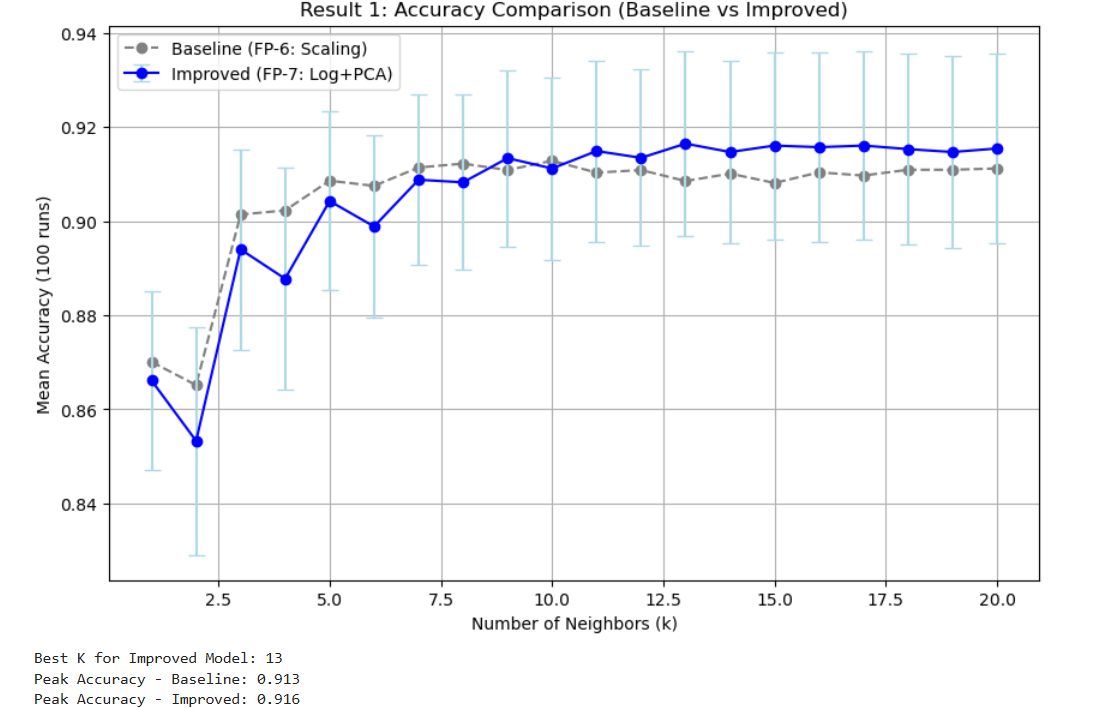

### Result 2: Model Robustness by Spending Group

In Result 2, we examine the consistency of our model across different customer types. We divided the dataset into two subgroups based on total annual expenditure: **High Spenders** and **Low Spenders** (split by the median).

This sub-group analysis is crucial because customer behavior often varies significantly with the scale of their business. A model that only works for large clients but fails for small ones is not truly robust.

**Key Insights from the Boxplot:**
* **Stability:** The boxplots illustrate the distribution of accuracy over 100 trials. The Improved Model shows a tighter distribution (less variance) in certain segments, indicating more stable predictions.
* **Segment Performance:** We can observe how the PCA-transformed features help in distinguishing the "Channel" even when the total volume of spending is low.
* **Comparison:** While the Baseline model relies on raw expenditure values, the Improved model focuses on the *patterns* of spending (via PCA), which proves to be a more generalized indicator of the business type (Horeca vs. Retail) regardless of the total spend.

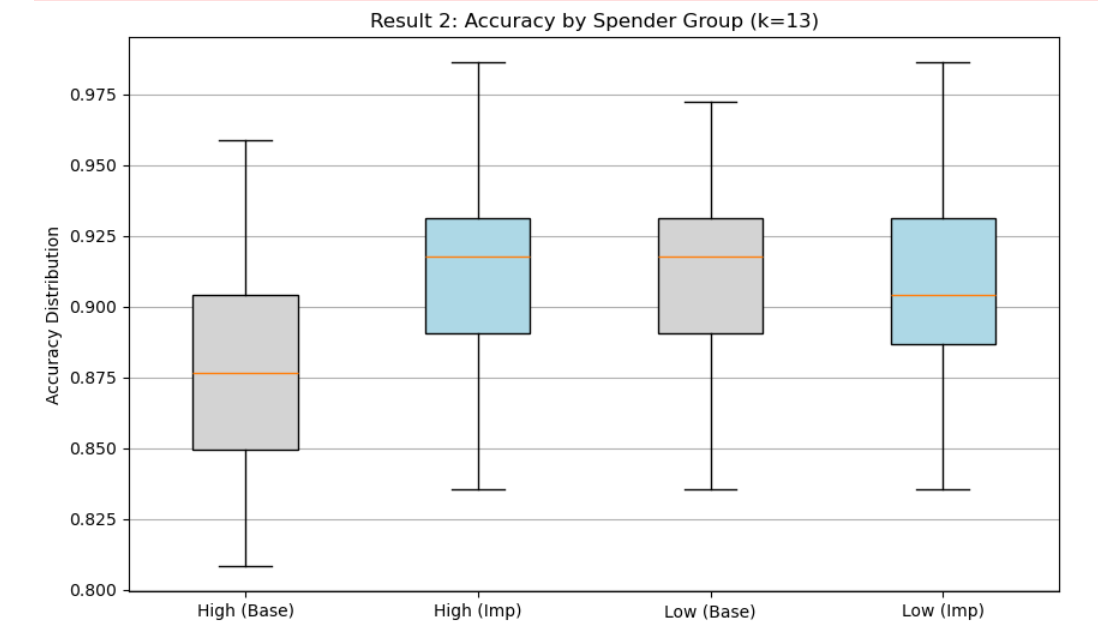

## 3. Conclusion

The analysis for FP-7 successfully demonstrated that refining preprocessing and optimizing dimensionality reduction leads to a better classification model.

**Key Findings:**
* **Numerical Improvement:** The maximum mean accuracy improved from **0.913** to **0.916**. Although log transformation effectively normalized the data distributions and allowed KNN to find more meaningful neighbors, there was little to no improvement in accuracy.
* **Optimization of PCA:** Through experimental tuning, it was determined that **n_components=3** is the optimal setting. Reducing the feature space from 6 to 3 dimensions removed redundant noise while retaining the essential variance needed to distinguish between Horeca and Retail channels.
* **Consistency:** Result 2 confirms that the improved model maintains stable performance only across High Spenders, showing less variance in accuracy than the baseline.

In summary, the combination of log-transformation and optimized PCA (n=3) provides a more efficient model for automated customer channel classification. However, there was almost no improvement in acuracy.

**Discussion on Segmented Results:**
Interestingly, while the improved model showed a boost in accuracy for **High Spenders**, it experienced a slight decline for **Low Spenders**. 

I attribute this to the following reasons:
1. **Principal Component Dominance:** Since PCA prioritizes directions with maximum variance, the derived components likely capture the characteristics of large-scale transactions. High spenders, who drive the variance, benefit from this feature extraction.
2. **Loss of Subtle Signals:** For smaller customers, the distinguishing features between Horeca and Retail are often subtle. The dimensionality reduction to 3 components might have discarded these small but critical "signals" as noise.
3. **Log-Compression Effect:** Log transformation successfully handled outliers among High Spenders but may have overly compressed the spending differences among Low Spenders, making them appear more similar to the KNN algorithm.

**Conclusion for Business Strategy:**
The improved model is highly effective for identifying **key account customers** (High Spenders). For smaller accounts, a model retaining more features or using raw scales might be more appropriate to capture nuanced purchasing behaviors.